In [1]:
# import the necessary packages
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import geopandas as gpd
import pandas as pd
from PIL import Image
import pillow_avif
import warnings
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# import geodatasets as geo

# load the low resolution world map
# url = "https://www.naturalearthdata.com/http//www.naturalearthdata.com/download/110m/cultural/ne_110m_admin_0_countries.zip"
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
# world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
world = gpd.read_file("ne_110m_admin_0_countries.zip")
# for k in world.keys(): print(k)
# print(world["CONTINENT"])


# Colour By Data

In [8]:
import requests
url = "https://dataunodc.un.org/sites/dataunodc.un.org/files/data_cts_intentional_homicide.xlsx"

response = requests.get(url)
file_Path = 'data_cts_intentional_homicide.xlsx'

if response.status_code == 200:
    with open(file_Path, 'wb') as file:
        file.write(response.content)
    print('File downloaded successfully')
else:
    print('Failed to download file')

File downloaded successfully


In [4]:
# gun_info = pd.read_csv("data_cts_intentional_homicide.xlsx")

gun_info = pd.read_excel("data_cts_intentional_homicide.xlsx") # download from "https://dataunodc.un.org/sites/dataunodc.un.org/files/data_cts_intentional_homicide.xlsx"
# gun_info = pd.read_excel("https://dataunodc.un.org/sites/dataunodc.un.org/files/data_cts_intentional_homicide.xlsx")
# row 2 contains the actual keys for each column
gun_info.iloc[1]
for head, flase_head in zip(gun_info.iloc[1], gun_info.keys()):
    # print(head, flase_head)
    gun_info = gun_info.rename(columns={flase_head: head})
gun_info = gun_info[2:]

In [140]:
gi_2023 = gun_info[gun_info["Year"] == "2023"]
gi_2023[gi_2023["Country"] == "Albania"]
gi_2023[gi_2023["Category"] == "Firearms or explosives - firearms"][gi_2023["Country"] == "Albania"]
gi_2023_firearms = gi_2023[gi_2023["Category"] == "Firearms or explosives - firearms"]
gi_2023_firearms_per100k = gi_2023[gi_2023["Category"] == "Firearms or explosives - firearms"][gi_2023["Unit of measurement"] == "Rate per 100,000 population"]
def gi_year(year, get=False):
    """ 
    gun info for the specified year
    options for get: "count", "per100k" """
    with warnings.catch_warnings(action="ignore"):
        if not get:
            return gun_info[gun_info["Category"] == "Firearms or explosives - firearms"][gun_info["Unit of measurement"] == "Rate per 100,000 population"][gun_info["Year"] == str(year)]
        else:
            if get == "count":
                return gun_info[gun_info["Category"] == "Firearms or explosives - firearms"][gun_info["Unit of measurement"] == "Counts"][gun_info["Year"] == str(year)]["VALUE"]
            if get == "per100k":
                return gun_info[gun_info["Category"] == "Firearms or explosives - firearms"][gun_info["Unit of measurement"] == "Rate per 100,000 population"][gun_info["Year"] == str(year)]["VALUE"]
        

# for i in range(2000, 2024):
#     print(i, len(gi_year(i)))


C:\Users\juvar\AppData\Local\Temp\ipykernel_24372\1674353870.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  gi_2023[gi_2023["Category"] == "Firearms or explosives - firearms"][gi_2023["Country"] == "Albania"]
C:\Users\juvar\AppData\Local\Temp\ipykernel_24372\1674353870.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  gi_2023_firearms_per100k = gi_2023[gi_2023["Category"] == "Firearms or explosives - firearms"][gi_2023["Unit of measurement"] == "Rate per 100,000 population"]


Error plotting Antigua and Barbuda: aspect must be finite and positive 
Error plotting Bosnia and Herzegovina: aspect must be finite and positive 
Error plotting Bermuda: aspect must be finite and positive 
Error plotting Bolivia (Plurinational State of): aspect must be finite and positive 
Error plotting Barbados: aspect must be finite and positive 
Error plotting Cabo Verde: aspect must be finite and positive 
Error plotting Dominica: aspect must be finite and positive 
Error plotting Dominican Republic: aspect must be finite and positive 
Error plotting United Kingdom (England and Wales): aspect must be finite and positive 
Error plotting United Kingdom (Northern Ireland): aspect must be finite and positive 
Error plotting United Kingdom (Scotland): aspect must be finite and positive 
Error plotting Grenada: aspect must be finite and positive 
Error plotting China, Hong Kong Special Administrative Region: aspect must be finite and positive 
Error plotting Saint Kitts and Nevis: aspe

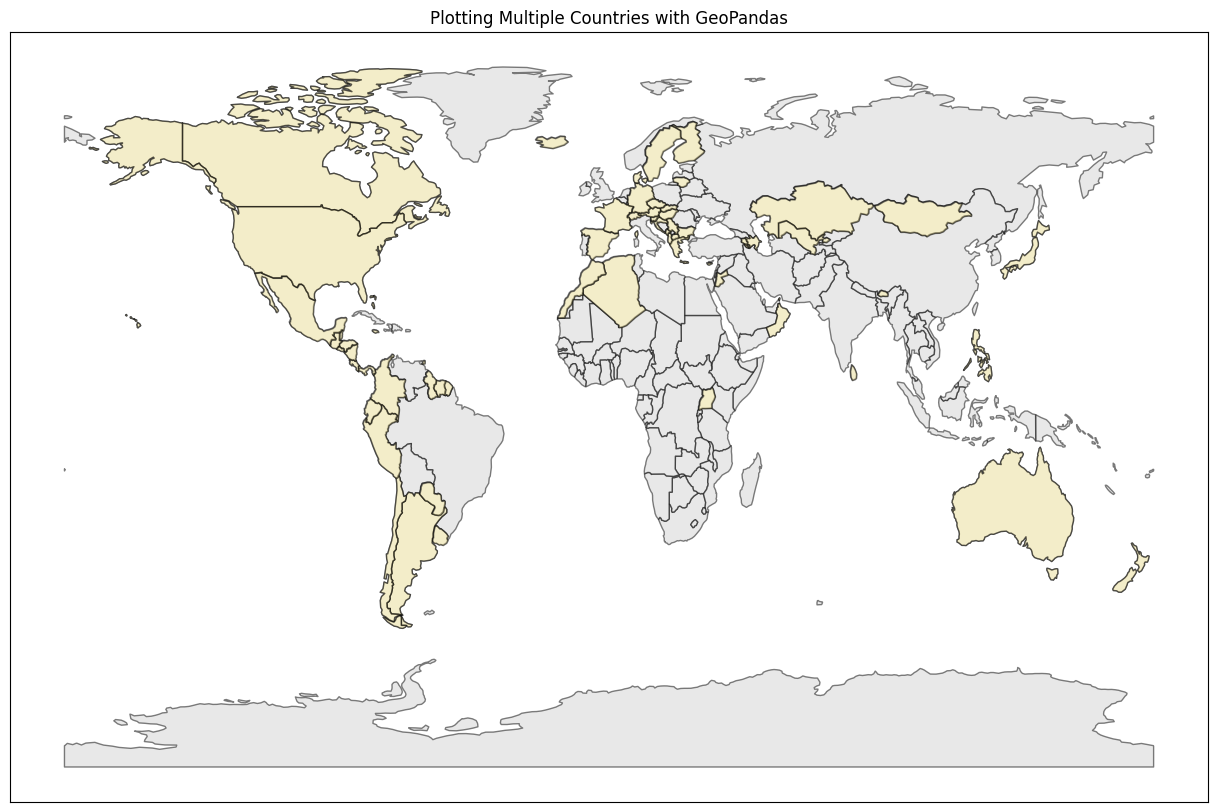

In [142]:
# initialize a new figure
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()


# define the names of the countries we want to plot
country_names = [
    "Chile",
    "Brazil",
    "Argentina",
    "United Kingdom",
    "Sweden",
    "Poland",
    "Denmark",
    "Netherlands",
    "Germany",
    "France",
    "Switzerland",
    "Austria",
    "Czech Republic",
    "Italy",
    "Spain",
    # "Kenya",
    # "Australia"
]
country_names = [c for c in gi_year(2017)["Country"]]

# grab multiple countries from the continent of Africa
countries = world[
    world["NAME"].isin(country_names)
]

# plot a map of the countries
world.plot(
    ax=ax,
    color="lightgray",
    edgecolor="black",
    alpha=0.5
)
# countries.plot(
#     ax=ax,
#     # cmap="Pastel1",
#     cmap = "Set3",
#     edgecolor="black",
#     alpha=0.5
# )
for country in country_names:
    # map the gi_year(2017,get="per100k") to a colour. Higher being redder
    c = gi_year(2017)[gi_year(2017)["Country"] == country]["VALUE"].values[0]
    c = (c - gi_year(2017,get="per100k").min()) / (gi_year(2017,get="per100k").max() - gi_year(2017,get="per100k").min())

    # plot the country
    countryp = world[world["NAME"] == country]
    try:
        countryp.plot(
            ax=ax,
            color=sns.color_palette("YlOrRd", 10)[int(c * 9)],
            edgecolor="black",
            alpha=0.5
        )
    except Exception as e:
        print(f"Error plotting {country}: {e}")

# turn off axis ticks
ax.set_xticks([])
ax.set_yticks([])

# set the plot title
plt.title("Plotting Multiple Countries with GeoPandas")
plt.show()

# Countries I've been to


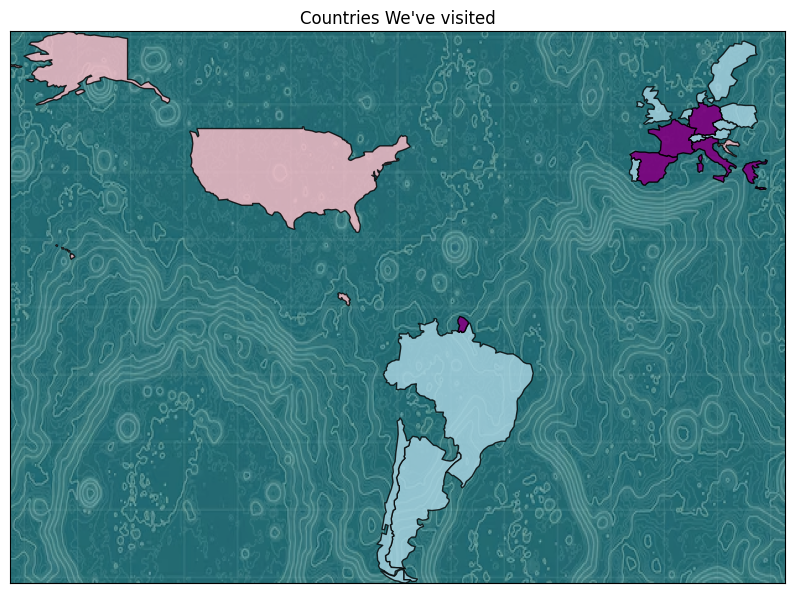

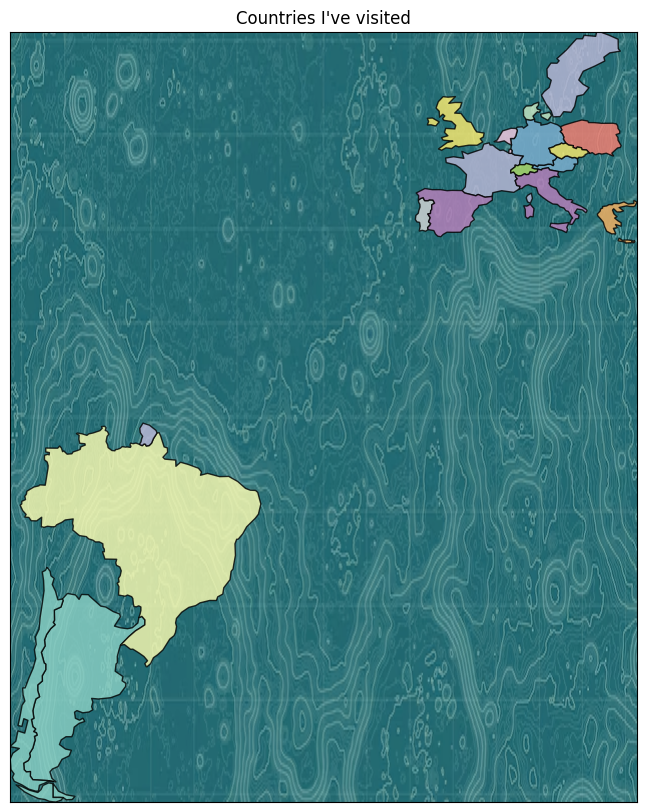

In [4]:
from country_plotting import plot_countries, plot_countries_combined

# define the names of the countries we want to plot
countries_J = [
"Chile", "Brazil",
"Argentina", "United Kingdom",
"Sweden", "Poland", 
"Denmark", "Netherlands",
"Germany", "France", "Luxembourg",
"Switzerland", "Austria", "Greece",
"Czechia", "Italy",
"Spain", "Portugal",
    # "Kenya",
    # "Australia"
]
countries_tg = [
"Germany", "France", "Greece", "Croatia", "Costa Rica", "Italy", "Spain", "United States of America"
]

plot_countries_combined(countries_tg, countries_J, background=True, world=world)
plot_countries(countries_J, background=True, world=world)